In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv("D:/IOT IDS/model/training_data.csv")

print(f"Total rows: {len(df)}")
print(f"\nClass distribution:")
print(df["label"].value_counts())
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nMissing values: {df.isnull().sum().sum()}")

Total rows: 513

Class distribution:
label
flood      138
normal     129
spoof      126
anomaly    120
Name: count, dtype: int64

First 3 rows:
   msg_count  mean_interval  std_interval  mean_payload_size  mean_temp  \
0          6         5.0007        0.0006             151.17      20.82   
1          6         5.0006        0.0002             151.83      20.59   
2          6         5.0007        0.0002             151.67      21.44   

   std_temp  mean_humidity  std_humidity  out_of_range_ratio  topic_depth  \
0    1.6758          59.79        1.9824                 0.0            4   
1    1.5652          59.60        2.4535                 0.0            4   
2    1.9762          60.48        3.5392                 0.0            4   

    label  
0  normal  
1  normal  
2  normal  

Missing values: 0


In [2]:
FEATURE_COLS = [
    "msg_count", "mean_interval", "std_interval",
    "mean_payload_size", "mean_temp", "std_temp",
    "mean_humidity", "std_humidity",
    "out_of_range_ratio", "topic_depth"
]

X = df[FEATURE_COLS]
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining set: {len(X_train)} rows")
print(f"Testing set:  {len(X_test)} rows")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Label encoding:
  anomaly → 0
  flood → 1
  normal → 2
  spoof → 3

Training set: 410 rows
Testing set:  103 rows

Classification Report:
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00        24
       flood       1.00      1.00      1.00        28
      normal       1.00      1.00      1.00        26
       spoof       1.00      1.00      1.00        25

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103



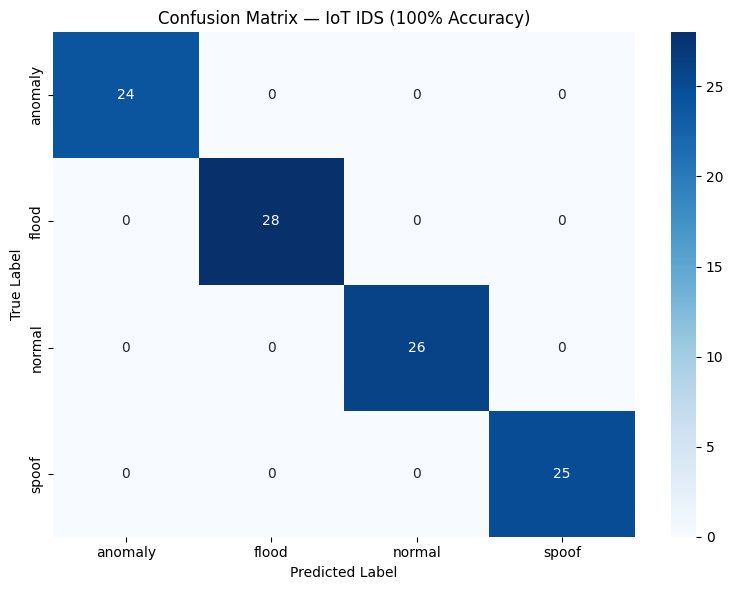

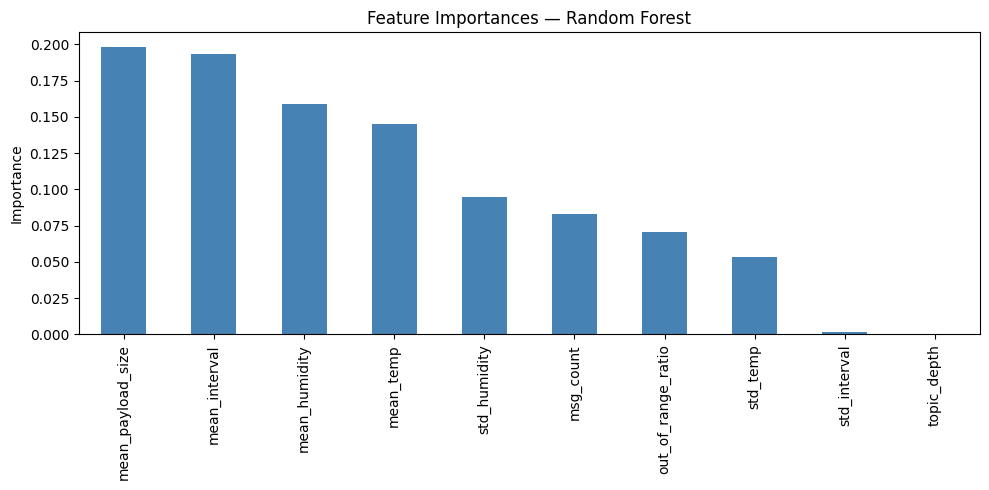

Feature Importances:
mean_payload_size     0.198390
mean_interval         0.193407
mean_humidity         0.159134
mean_temp             0.144905
std_humidity          0.094873
msg_count             0.083044
out_of_range_ratio    0.070874
std_temp              0.053435
std_interval          0.001938
topic_depth           0.000000
dtype: float64


In [3]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix — IoT IDS (100% Accuracy)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("D:/IOT IDS/model/confusion_matrix.png", dpi=150)
plt.show()

# Feature importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind="bar", color="steelblue")
plt.title("Feature Importances — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("D:/IOT IDS/model/feature_importance.png", dpi=150)
plt.show()

print("Feature Importances:")
print(importances)

In [4]:
import json

MODEL_PATH = "D:/IOT IDS/model/"

# Save model
joblib.dump(rf_model, MODEL_PATH + "random_forest.pkl")

# Save label encoder
joblib.dump(le, MODEL_PATH + "label_encoder.pkl")

# Save feature list
with open(MODEL_PATH + "features.json", "w") as f:
    json.dump(FEATURE_COLS, f)

# Verify
model_loaded = joblib.load(MODEL_PATH + "random_forest.pkl")
le_loaded    = joblib.load(MODEL_PATH + "label_encoder.pkl")

test_sample  = X_test.iloc[:1]
prediction   = model_loaded.predict(test_sample)[0]
label        = le_loaded.inverse_transform([prediction])[0]
confidence   = model_loaded.predict_proba(test_sample).max()

print("Model saved successfully.")
print(f"\nVerification:")
print(f"  Sample features: {test_sample.values[0]}")
print(f"  Prediction:      {label}")
print(f"  Confidence:      {confidence:.4f}")

Model saved successfully.

Verification:
  Sample features: [6.0000e+00 5.0004e+00 7.0000e-04 1.7300e+02 8.7000e+01 0.0000e+00
 5.0000e+00 0.0000e+00 1.0000e+00 4.0000e+00]
  Prediction:      spoof
  Confidence:      1.0000
